# CHAPTER-21_______________________________________________Bias Variance Trade-of

**Bias**: The ability of a machine learning model to capture the relationship in the traning data  
**Variance** It is the difference between fits in different data sets  
_for example_  
* Error in traning data = 10
* Error in testing data = 50
* _variance_ = **50 - 10 = 40**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("Position_Salaries.csv")
print(f"data's shape = {data.shape}")
data.sample(2)

data's shape = (10, 3)


,Position,Level,Salary
2,Senior Consultant,3,60000
4,Country Manager,5,110000


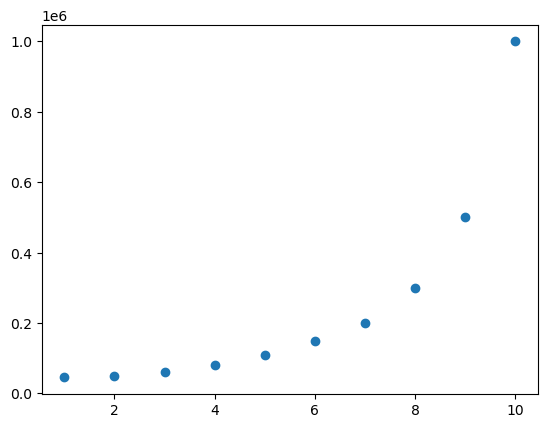

In [3]:
plt.scatter(x=data["Level"],y=data["Salary"])

In [4]:
x=data.iloc[:,[1]]
y=data["Salary"]
from sklearn.preprocessing import PolynomialFeatures

poly_0nedegree = PolynomialFeatures(degree=1)
poly_Fourdegree = PolynomialFeatures(degree=3)
poly_Eightdegree = PolynomialFeatures(degree=8)

x_one_degree_poly = poly_0nedegree.fit_transform(x)
x_four_degree_poly = poly_Fourdegree.fit_transform(x)
x_eight_degree_poly = poly_Eightdegree.fit_transform(x)

print(f"one = {x_one_degree_poly[0]} \n four = {x_four_degree_poly[0]} \n eight ={x_eight_degree_poly[0]}")

one = [1. 1.] 
 four = [1. 1. 1. 1.] 
 eight =[1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [5]:
from sklearn.linear_model import LinearRegression
plr_one_scaler = LinearRegression()
plr_four_scaler = LinearRegression()
plr_eight_scaler = LinearRegression()

plr_one_scaler.fit(x_one_degree_poly,y)
plr_four_scaler.fit(x_four_degree_poly,y)
plr_eight_scaler.fit(x_eight_degree_poly,y)

LinearRegression()

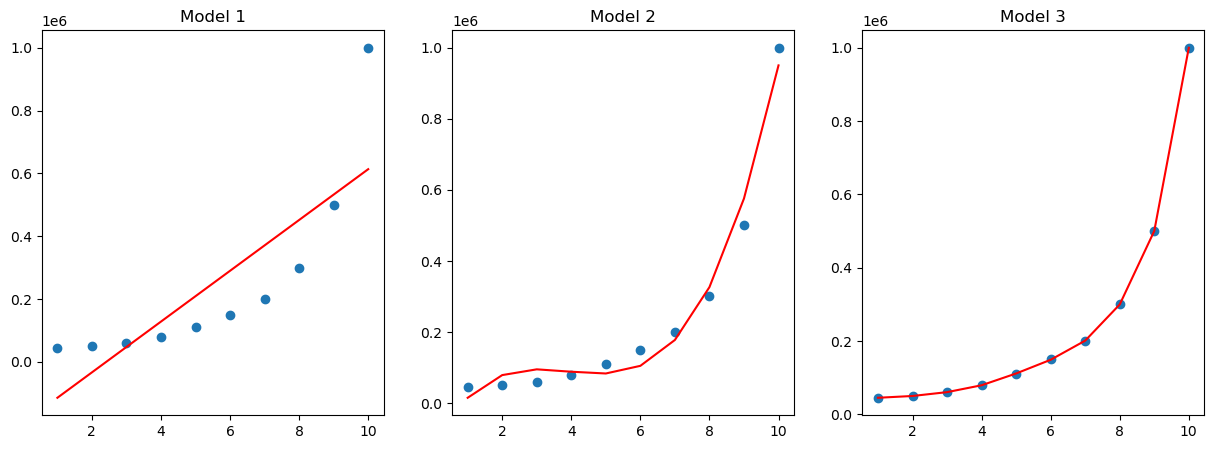

In [6]:
fig,ax = plt.subplots(ncols=3,figsize=(15,5))

ax[0].set_title("Model 1")
ax[1].set_title("Model 2")
ax[2].set_title("Model 3")

ax[0].scatter(y=data["Salary"],x=data["Level"])
ax[1].scatter(y=data["Salary"],x=data["Level"])
ax[2].scatter(y=data["Salary"],x=data["Level"])

# predictions of the models
ax[0].plot(data["Level"],plr_one_scaler.predict(x_one_degree_poly),color="red")
ax[1].plot(data["Level"],plr_four_scaler.predict(x_four_degree_poly),color="red")
ax[2].plot(data["Level"],plr_eight_scaler.predict(x_eight_degree_poly),color="red")

| Model-1 | Model-1 | Model-1 |
|---------|---------|---------|
|**High** Bias|**Low** Bias|**Low** Bias|
|**low** Variance|**low** Variance|**High** Variance|
|Under FIT| Best FIT |Over FIT|

# CHAPTER-22_______________________________________________cross validation

_Cross-validation in machine learning is a resampling procedure used to evaluate the performance of a machine learning model on a limited data sample and assess how the results will generalize to an independent dataset._

**TYPES**  
* KFold
* StratifiedKFold
* GroupKFold
* StratifiedGroupKFold

In [7]:
data = pd.read_csv("heart_attack_dataset.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet                

In [19]:
columns = [x for x in data.columns if data[x].dtype=="int64"]
columns

['Age',
 'Cholesterol',
 'Heart Rate',
 'Diabetes',
 'Family History',
 'Smoking',
 'Obesity',
 'Alcohol Consumption',
 'Previous Heart Problems',
 'Medication Use',
 'Stress Level',
 'Income',
 'Triglycerides',
 'Physical Activity Days Per Week',
 'Sleep Hours Per Day',
 'Heart Attack Risk']

In [30]:
x=data[columns].iloc[:,:-1]
y=data[columns].iloc[:,[-1]]
print(f"x shape {x.shape}, y shape {y.shape}")

x shape (8763, 15), y shape (8763, 1)


In [56]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size=0.25,shuffle=True)
print(f"x train={xtrain.shape},{xtrain.size}")
print(f"x test={xtest.shape},{xtest.size}")

x train=(6572, 15),98580
x test=(2191, 15),32865


In [57]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(xtrain,ytrain)

C:\Users\updes\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GaussianNB()

In [60]:
nb.predict(xtrain)

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [62]:
# predictiong the probablity of being 1 or zero
nb.predict_proba(xtrain)

array([[0.64098937, 0.35901063],
       [0.63800877, 0.36199123],
       [0.64155934, 0.35844066],
       ...,
       [0.67022417, 0.32977583],
       [0.6387642 , 0.3612358 ],
       [0.63454343, 0.36545657]])

In [65]:
from sklearn.metrics import accuracy_score, roc_auc_score
acc = accuracy_score(ytrain,nb.predict(xtrain))
roc = roc_auc_score(ytrain,nb.predict_proba(xtrain)[:,-1])
print(f"The score of the traning set is {acc:0.4f}, and auc is {roc:0.4f}")

The score of the traning set is 0.6400, and auc is 0.5286


In [66]:
# accuracy with actual data
acc = accuracy_score(ytest,nb.predict(xtest))
roc = roc_auc_score(ytest,nb.predict_proba(xtest)[:,-1])
print(f"The score of the traning set is {acc:0.4f}, and auc is {roc:0.4f}")

The score of the traning set is 0.6472, and auc is 0.5079


### chacking the score of a base zero and one

In [67]:
accuracy_score(ytrain,np.zeros_like(ytrain)),roc_auc_score(ytrain,np.zeros_like(ytrain))

(0.6399878271454656, 0.5)

In [70]:
accuracy_score(ytrain,np.ones_like(ytrain)),roc_auc_score(ytrain,np.ones_like(ytrain))

(0.3600121728545344, 0.5)

### as we can see that our model is simply gessing the result

<div class="alert alert-warning"><center><h2>KFold</h2></center></div>

ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not       Heart Attack Risk
0                     0
1                     0
2                     0
3                     0
4                     0
...                 ...
8758                  0
8759                  0
8760                  1
8761                  0
8762                  1

[8763 rows x 1 columns]

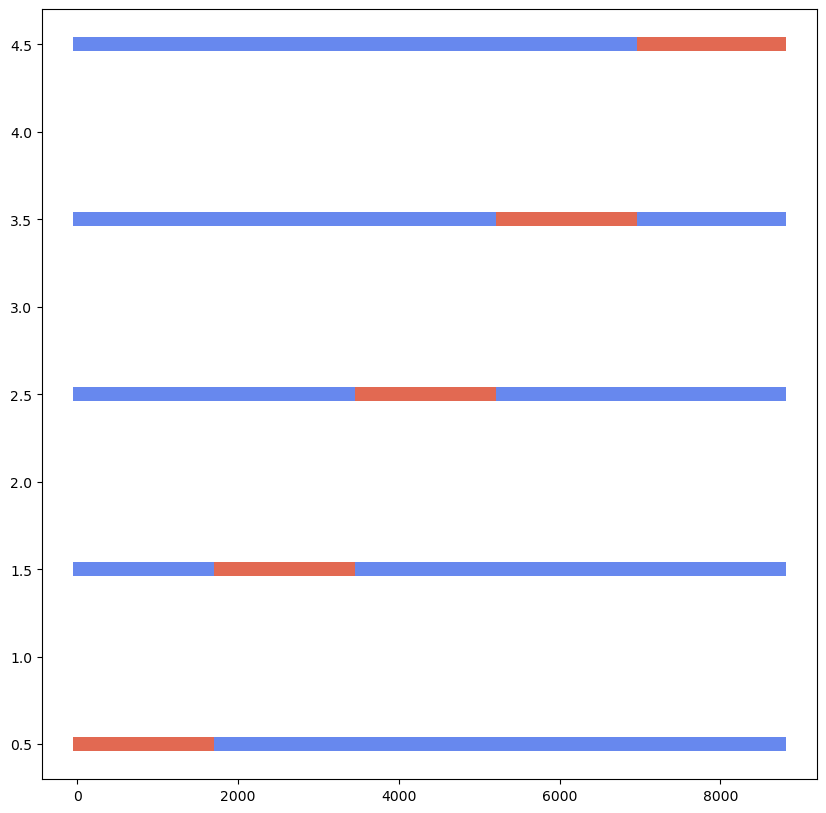

In [96]:
from sklearn.model_selection import KFold
kf = KFold(shuffle=False)
cmap_data = plt.cm.Paired
cmap_cv = plt.cm.coolwarm

fig,ax = plt.subplots(ncols=1,figsize=(10,10))
plot_cv(kf, x,y,cmap_data,ax,5)

# CHAPTER-23_______________________________________________Pipeline

# CHAPTER-24_______________________________________________column Transformers